# Reproducing experiments

To run this experiment, make sure to install all required packages (the bsarec environment), and to activate this before running the code in this file.

In [ ]:
import sys
import os
os.chdir("src")
import torch
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
from model import MODEL_DICT
from trainers import Trainer, FICLRecTrainer
from utils import EarlyStopping, check_path, set_seed, parse_args, set_logger
from dataset import get_seq_dic, get_dataloder, get_rating_matrix
import wandb
from main import main

Ensure GPU availability to run in acceptable time-period. Training the example takes +/- 2 minutes on an a100 GPU. 

In [23]:
os.environ["WANDB_MODE"] = "disabled"

!python main.py  --data_name LastFM \
                --lr 0.0005 \
                --alpha 0.7 \
                --batch_size 2048 \
                --c 5 \
                --num_attention_heads 1 \
                --save \
                --train_name LastFM_example 

2025-06-26 16:06:10,112 - Namespace(data_dir='./data/', output_dir='output/', data_name='LastFM', do_eval=False, load_model=None, train_name='LastFM_example', num_items=10, num_users=1091, lr=0.0005, batch_size=2048, epochs=200, no_cuda=False, log_freq=1, patience=10, num_workers=4, seed=42, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, gpu_id='0', variance=5, padding='zero', model_type='BSARec', max_seq_length=50, hidden_size=64, num_hidden_layers=2, hidden_act='gelu', num_attention_heads=1, attention_probs_dropout_prob=0.5, hidden_dropout_prob=0.5, initializer_range=0.02, project='BSARec', run_name='BSARec', wandb_log_freq_model=10, wandb_log_model=False, save=True, save_path='output/', spectral=False, c=5, alpha=0.7, no_padding=False, flip_zero_padding=False, job_id='12646543', cuda_condition=True, data_file='./data/LastFM.txt', item_size=3647, checkpoint_path='output/LastFM_example.pt', same_target_path='./data/LastFM_same_target50.npy')
2025-06-26 16:06:10,122 - BSARecModel(

In [24]:
!python main.py  --data_name LastFM \
                --lr 0.0005 \
                --alpha 0.7 \
                --c 5 \
                --num_attention_heads 1 \
                --train_name LastFM_example \
                --load_model LastFM_example \
                --do_eval

2025-06-26 16:09:05,349 - Namespace(data_dir='./data/', output_dir='output/', data_name='LastFM', do_eval=True, load_model='LastFM_example', train_name='LastFM_example', num_items=10, num_users=1091, lr=0.0005, batch_size=256, epochs=200, no_cuda=False, log_freq=1, patience=10, num_workers=4, seed=42, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, gpu_id='0', variance=5, padding='zero', model_type='BSARec', max_seq_length=50, hidden_size=64, num_hidden_layers=2, hidden_act='gelu', num_attention_heads=1, attention_probs_dropout_prob=0.5, hidden_dropout_prob=0.5, initializer_range=0.02, project='BSARec', run_name='BSARec', wandb_log_freq_model=10, wandb_log_model=False, save=False, save_path='output/', spectral=False, c=5, alpha=0.7, no_padding=False, flip_zero_padding=False, job_id='12646543', cuda_condition=True, data_file='./data/LastFM.txt', item_size=3647, checkpoint_path='output/LastFM_example.pt', same_target_path='./data/LastFM_same_target50.npy')
2025-06-26 16:09:05,360 - B

Pandas, sklearn and Matplotlib are a necessary module to add to the BSARec environment in order to compute fairness. To ensure continuity for the original BSARec environment, we have not changed it. Make sure to install pandas, or simply run the command below, note the argument '-y', which immediately accepts changes. 

In [60]:
# !conda install -y pandas
# !conda install -y scikit-learn
# !conda install -y matplotlib
!conda install -y seaborn

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.7.2
  latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=25.5.1



# All requested packages already installed.



# Using Non-zero padding (RQ4)

In [54]:
!python main.py  --data_name LastFM \
                --lr 0.0005 \
                --alpha 0.7 \
                --batch_size 8192 \
                --c 5 \
                --num_attention_heads 1 \
                --save \
                --padding reflect \
                --train_name LastFM_example_padding

/home/user/.conda/envs/bsarec/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
2025-06-26 16:43:46,525 - Namespace(data_dir='./data/', output_dir='output/', data_name='LastFM', do_eval=False, load_model=None, train_name='LastFM_example_padding', num_items=10, num_users=1091, lr=0.0005, batch_size=8192, epochs=200, no_cuda=False, log_freq=1, patience=10, num_workers=4, seed=42, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, gpu_id='0', variance=5, padding='reflect', model_type='BSARec', max_seq_length=50, hidden_size=64, num_hidden_layers=2, hidden_act='gelu', num_attention_heads=1, attention_probs_dropout_prob=0.5, hidden_dropout_prob=0.5, initializer_range=0.02, project='BSARec', run_name='BSARec', wandb_log_freq_model=10, wandb_log_model=False, save=True, save_path='output/', spectral=False, c=5, alpha=0.7, no_padding=False, flip_zero_padding=

In [55]:
!python main.py  --data_name LastFM \
                --lr 0.0005 \
                --alpha 0.7 \
                --c 5 \
                --num_attention_heads 1 \
                --train_name LastFM_example_padding \
                --load_model LastFM_example_padding \
                --do_eval

/home/user/.conda/envs/bsarec/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
2025-06-26 16:47:19,953 - Namespace(data_dir='./data/', output_dir='output/', data_name='LastFM', do_eval=True, load_model='LastFM_example_padding', train_name='LastFM_example_padding', num_items=10, num_users=1091, lr=0.0005, batch_size=256, epochs=200, no_cuda=False, log_freq=1, patience=10, num_workers=4, seed=42, weight_decay=0.0, adam_beta1=0.9, adam_beta2=0.999, gpu_id='0', variance=5, padding='zero', model_type='BSARec', max_seq_length=50, hidden_size=64, num_hidden_layers=2, hidden_act='gelu', num_attention_heads=1, attention_probs_dropout_prob=0.5, hidden_dropout_prob=0.5, initializer_range=0.02, project='BSARec', run_name='BSARec', wandb_log_freq_model=10, wandb_log_model=False, save=False, save_path='output/', spectral=False, c=5, alpha=0.7, no_padding=False, fl

In [71]:
%%capture cap --no-stderr

import datetime
from types import SimpleNamespace
from dataset import get_seq_dic, get_dataloder, get_rating_matrix

def get_local_time():
    cur = datetime.datetime.now()
    cur = cur.strftime('%b-%d-%Y_%H-%M-%S')

    return cur

args = {}
args["data_dir"]= "./data/"
args["output_dir"]= "output/"
args["data_name"]= "LastFM"
args["do_eval"]= True
args["load_model"]="output/LastFM_example"
args["train_name"]=get_local_time()
args["num_items"]=10
args["num_users"]=10

# train args
args["lr"]=0.0005
args["batch_size"]=256
args["epochs"]=200
args["no_cuda"]= True
args["log_freq"]=1
args["patience"]=10
args["num_workers"]=4
args["c"]=3
args["alpha"]=0.9

args["seed"]=42
args["weight_decay"]=0.0
args["adam_beta1"]=0.9
args["adam_beta2"]=0.999
args["gpu_id"]= "0"
args["variance"]=5

# model args
args["model_type"]='BSARec'
args["max_seq_length"]=50
args["hidden_size"]=64
args["num_hidden_layers"]=2
args["hidden_act"]= "gelu"
args["num_attention_heads"]=2
args["attention_probs_dropout_prob"]=0.5
args["hidden_dropout_prob"]=0.5
args["initializer_range"]=0.02

# for wandb only
args["project"] = 'BSARec'
args["run_name"] = 'BSARec'

# saving all model logits
args["save"]=True
args["save_path"]="output/"

args["spectral"]=True
args = SimpleNamespace(**args)

seq_dic, max_item, num_users = get_seq_dic(args)
args.item_size = max_item + 1
args.num_users = num_users + 1
args.valid_rating_matrix, args.test_rating_matrix = get_rating_matrix(args.data_name, seq_dic, max_item)

import os
import torch
import numpy as np

from model import MODEL_DICT
from trainers import Trainer
from utils import EarlyStopping, check_path, set_seed, set_logger
from dataset import get_seq_dic, get_dataloder, get_rating_matrix
import wandb
from types import SimpleNamespace
from model.bsarec import FrequencyLayer

log_path = os.path.join(args.output_dir, args.train_name + '.log')
logger = set_logger(log_path)

set_seed(args.seed)
check_path(args.output_dir)

os.environ["CUDA_VISIBLE_DEVICES"] = args.gpu_id
args.cuda_condition = torch.cuda.is_available() and not args.no_cuda

seq_dic, max_item, num_users = get_seq_dic(args)
args.item_size = max_item + 1
args.num_users = num_users + 1

args.checkpoint_path = os.path.join(args.output_dir, args.train_name + '.pt')
args.same_target_path = os.path.join(args.data_dir, args.data_name+'_same_target.npy')

from trainers import Trainer


SAVE_TENSORS_FILE_BSA_REC = f"./analysis_lastfm_bsarec_tensors.pt"
SAVE_TENSORS_REMOVE_PADDING = f"./analysis_lastfm_bsarec_nopadding.pt"
SAVE_TENSORS_REFLECT_PADDING = f"./analysis_lastfm_bsarec_reflect_padding.pt"

args.checkpoint_path = os.path.join(args.output_dir, args.load_model + '.pt')


def save_bsarec_file(checkpoint_path, model_type=args.model_type.lower(), padding="zero", save_file=SAVE_TENSORS_FILE_BSA_REC):
    args.checkpoint_path = checkpoint_path
    args.model_type = model_type
    args.padding = padding
    train_dataloader, eval_dataloader, test_dataloader, _ = get_dataloder(args,seq_dic)

    # logger.info(str(args))
    model = MODEL_DICT[model_type](args=args)
    # logger.info(model)
    trainer = Trainer(model, train_dataloader, eval_dataloader, test_dataloader, args, logger, wandb=False)
    trainer.load(checkpoint_path, map_location=torch.device('cpu'))

    logger.info(f"Load model from {checkpoint_path} for test!")
    # scores, result_info = trainer.test(epoch=args.epochs - 1, save=args.save, spectral=args.spectral)
    trainer.model.eval()

    trainer.model.eval()
    with torch.no_grad():
        batch = next(iter(eval_dataloader))
        batch = tuple(t.to(trainer.device) for t in batch)
        user_ids, input_ids, answers, neg_answer, same_target = batch
        trainer.model.to(trainer.device)

        # put input through positional embeddings
        pos_emb_input = trainer.model.add_position_embedding(input_ids)
        att_mask = trainer.model.get_attention_mask(input_ids)

        # first block layer

        # Get high and low frequencies
        freqs_input = torch.clone(pos_emb_input)

        _, seq_len, _ = freqs_input.shape
        x = torch.fft.rfft(freqs_input, dim=1, norm='ortho')
        
        low_pass = x[:]
        low_pass[:, trainer.model.item_encoder.blocks[0].layer.filter_layer.c:, :] = 0
        low_pass = torch.fft.irfft(low_pass, n=seq_len, dim=1, norm='ortho')
        high_pass = freqs_input - low_pass
        sequence_emb_fft = low_pass + (trainer.model.item_encoder.blocks[0].layer.filter_layer.sqrt_beta**2) * high_pass

        # Get combined frequencies
        filter_out = trainer.model.item_encoder.blocks[0].layer.filter_layer.LayerNorm(sequence_emb_fft + freqs_input)

        # Get multi-head attention layer
        mha_tensor = torch.clone(pos_emb_input)
        mha_tensor = trainer.model.item_encoder.blocks[0].layer.attention_layer(mha_tensor, att_mask)

        # get first block combined
        hidden_states = trainer.model.item_encoder.blocks[0].layer.alpha * filter_out + ( 1 - trainer.model.item_encoder.blocks[0].layer.alpha ) * mha_tensor

        # pass through the FFNN
        output_block = trainer.model.item_encoder.blocks[0].feed_forward(hidden_states)

        # second block layer
        output_block_all = torch.clone(pos_emb_input)
        output_block_all = trainer.model.item_encoder.blocks[0](output_block_all, att_mask)

        # Get high and low frequencies
        pos_emb_input2 = torch.clone(output_block_all)
        freqs_input2 = torch.clone(pos_emb_input2)

        _, seq_len, _ = freqs_input2.shape
        x2 = torch.fft.rfft(freqs_input2, dim=1, norm='ortho')
        
        low_pass2 = x2[:]
        low_pass2[:, trainer.model.item_encoder.blocks[1].layer.filter_layer.c:, :] = 0
        low_pass2 = torch.fft.irfft(low_pass2, n=seq_len, dim=1, norm='ortho')
        high_pass2 = freqs_input2 - low_pass2
        sequence_emb_fft2 = low_pass2 + (trainer.model.item_encoder.blocks[1].layer.filter_layer.sqrt_beta**2) * high_pass2

        # Get combined frequencies
        filter_out2 = trainer.model.item_encoder.blocks[1].layer.filter_layer.LayerNorm(sequence_emb_fft2 + freqs_input2)

        # Get multi-head attention layer
        mha_tensor2 = torch.clone(pos_emb_input2)
        mha_tensor2 = trainer.model.item_encoder.blocks[1].layer.attention_layer(mha_tensor2, att_mask)

        # get first block combined
        hidden_states2 = trainer.model.item_encoder.blocks[1].layer.alpha * filter_out2 + ( 1 - trainer.model.item_encoder.blocks[1].layer.alpha ) * mha_tensor2

        # pass through the FFNN
        output_block2 = trainer.model.item_encoder.blocks[1].feed_forward(hidden_states2)

        # second block layer
        output_block_all2 = torch.clone(pos_emb_input2)
        pos_emb_input = trainer.model.add_position_embedding(input_ids)
        att_mask = trainer.model.get_attention_mask(input_ids)
        output_block_all2 = trainer.model.forward(input_ids)

        


        tensor_dict = {
            "original_users": user_ids.cpu(),
            "original_input": input_ids.cpu(),
            "positional_embedding_input": pos_emb_input.cpu(),
            "low_pass_component": low_pass.cpu(),
            "high_pass_component": high_pass.cpu(),
            "sequence_emb_fft": sequence_emb_fft.cpu(),
            "filtered_output": filter_out.cpu(),
            "multihead_attention_output": mha_tensor.cpu(),
            "combined_hidden_state": hidden_states.cpu(),
            "full_block_manual": output_block.cpu(),
            "full_block_output": output_block_all.cpu(),
            "low_pass_component2": low_pass2.cpu(),
            "high_pass_component2": high_pass2.cpu(),
            "sequence_emb_fft2": sequence_emb_fft2.cpu(),
            "filtered_output2": filter_out2.cpu(),
            "multihead_attention_output2": mha_tensor2.cpu(),
            "combined_hidden_state2": hidden_states2.cpu(),
            "full_block_manual2": output_block2.cpu(),
            "full_block_output2": output_block_all2.cpu()
        }

        torch.save(tensor_dict, save_file)
        
        # Check to see if no steps were skipped
        assert torch.equal(output_block, output_block_all)
        assert torch.equal(output_block2, output_block_all2)

# save_bsarec_file("/scratch-shared/recsys/BSARec_LastFM_lr_0.001_bs_256_ep_200_seed_1417", "BSARec", "zero", )

save_bsarec_file("output/LastFM_example.pt", model_type="bsarec", padding="zero", save_file=SAVE_TENSORS_FILE_BSA_REC)

save_bsarec_file("output/LastFM_example_padding.pt", "bsarec", "reflect", SAVE_TENSORS_REFLECT_PADDING)
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def load_tensor_dict(pt_path):
    data = torch.load(pt_path, map_location='cpu')
    return data

def compute_l2_norms(tensor_dict, tensor_names):
    norms = {}
    for name in tensor_names:
        if len(tensor_dict[name].shape) < 3:
            norms[name] = tensor_dict[name].cpu().numpy()
        else:
            arr = tensor_dict[name].cpu().numpy()
            norms[name] = np.linalg.norm(arr, axis=-1)
    return norms

def plot_user_barplots_two(tensor_dict,
                            norms_dict_zero,
                            norms_dict_reflect,
                            tensor_names,
                            inputs,
                            n_users=5,
                            save_dir="barplots",
                            font_size=22):
    """
    For each of the first n_users:
      - Colors bars by item ID mapped to class-color
      - Displays inline and saves PNGs
      - Plots two padding variants on two rows: zero padding, reflect
      - Ensures all columns share the same y-axis scaling per user
    """
    os.makedirs(save_dir, exist_ok=True)
    n_tensors = len(tensor_names)
    n_items = norms_dict_zero[tensor_names[0]].shape[1]
    x = np.arange(n_items)
    actual_color = plt.get_cmap('tab20').colors[0]
    plt.rcParams.update({'font.size': font_size})

    for user_idx in range(min(n_users, norms_dict_zero[tensor_names[0]].shape[0])):
        max_vals = []
        for norm_dict in (norms_dict_zero, norms_dict_reflect):
            for name in tensor_names:
                max_vals.append(np.max(norm_dict[name][user_idx]))
        global_max = max(max_vals)

        item_ids = tensor_dict[inputs][user_idx]
        colors = ['darkgrey' if itm == 0 else actual_color for itm in item_ids]

        fig, axes = plt.subplots(2, n_tensors, figsize=(4 * n_tensors, 6), squeeze=True, sharex=True, sharey=True)

        row_titles = ['zero', 'reflect']
        norm_dicts = [norms_dict_zero, norms_dict_reflect]

        tensor_names_titles = ["Low-frequency", "High-frequency"]  # adjust if needed

        for row_idx, (title, norm_dict) in enumerate(zip(row_titles, norm_dicts)):
            for col, name in enumerate(tensor_names):
                ax = axes[row_idx, col]
                user_vec = norm_dict[name][user_idx]
                ax.bar(x, user_vec, color=colors)
                ax.set_title(f"{tensor_names_titles[col]} ({title})")
                if col == 0:
                    ax.set_ylabel("L2 norm")
                ax.set_xlabel("Item index")
                ax.set_xticks([])
                ax.set_ylim(0, global_max * 1.05)

        padding_patch = mpatches.Patch(color='darkgrey', label='Padding')
        actual_patch = mpatches.Patch(color=actual_color, label='Actual Items')
        fig.legend(handles=[padding_patch, actual_patch], loc="lower center", frameon=False, ncol=2)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fig.subplots_adjust(bottom=0.12)

        out_path_png = os.path.join(save_dir, f"user_{user_idx:02d}_barplots.png")
        fig.savefig(out_path_png, dpi=150)

        out_path_pdf = os.path.join(save_dir, f"user_{user_idx:02d}_barplots.pdf")
        fig.savefig(out_path_pdf, dpi=300, format="pdf")

        print(f"Saved bar plot for user {user_idx} at {out_path_pdf}")
        plt.show()


tensor_names = [
    "original_users",
    "original_input",
    "positional_embedding_input",
    "low_pass_component",
    "high_pass_component",
    "sequence_emb_fft",
    "filtered_output",
    "multihead_attention_output",
    "combined_hidden_state",
    "full_block_manual",
    "full_block_output",
    "low_pass_component2",
    "high_pass_component2",
    "sequence_emb_fft2",
    "filtered_output2",
    "multihead_attention_output2",
    "combined_hidden_state2",
    "full_block_manual2",
    "full_block_output2"
]

# Load & compute for zero-padding
tensor_dict = load_tensor_dict(SAVE_TENSORS_FILE_BSA_REC)
norms_zero = compute_l2_norms(tensor_dict, tensor_names)

# Load & compute for reflect-padding
tensor_dict_reflect = load_tensor_dict(SAVE_TENSORS_REFLECT_PADDING)
norms_reflect = compute_l2_norms(tensor_dict_reflect, tensor_names)

selected_tensors = [
    "low_pass_component",
    "high_pass_component",
]




2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,601 - Total Parameters: 337088
2025-06-26 16:58:35,606 - odict_keys(['item_embeddings.weight', 'position_embeddings.weight', 'LayerNorm.weight', 'LayerNorm.bias', 'item_encoder.blocks.0.layer.filter_layer.sqrt_beta', 'item_encoder.blocks.0.layer.filter_layer.LayerNorm.weight', 'item_encoder.blocks.0.layer.filter_layer.LayerNorm.bias', 'item_encoder.blocks.0.layer.attention_layer.query.weight', 'item_encoder.blocks.0.layer.attention_layer.query.bias', 'item_encoder.b

Saved bar plot for user 0 at barplots/user_00_barplots.pdf


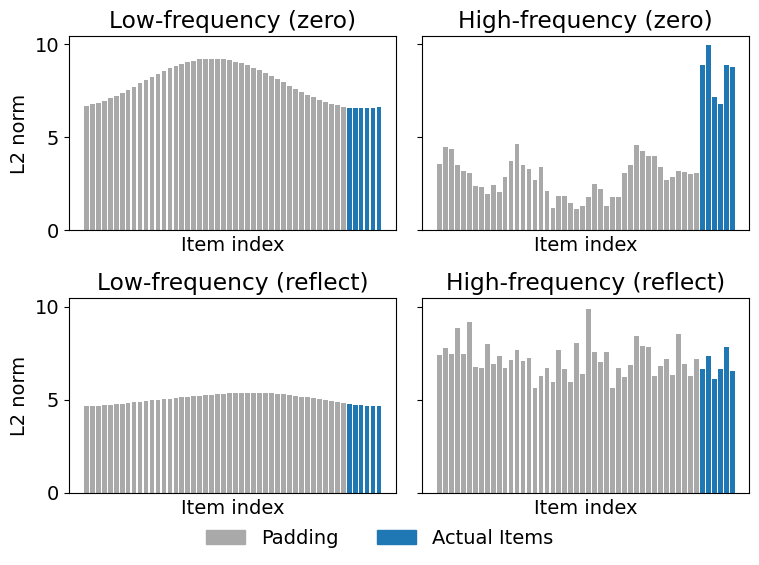

In [73]:
n = 1  # number of users, change to view more users

plot_user_barplots_two(
    tensor_dict,
    norms_zero,
    norms_reflect,
    selected_tensors,
    inputs="original_input",
    n_users=n,
    font_size=14
)

Other visualizations of experiments can be found in `src/visualize/`. As these require multiple runs in order to show accurate visualizations, we have elected to include only the previously shown parts in our current analysis. In `README.md`, we include full instructions on how to run all models. Optionally, it is also possible to run these models using the hyperparameter tuning files available in `experiments/`. Afterwards, the jupyter notebooks can be ran from `src/visualize/` to reproduce all visualizations in our paper.